In [2]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os
import kagglehub 
path = kagglehub.dataset_download("mabubakrsiddiq/students-learning-trajectory")
print("Path to dataset files:", path)

c:\Users\HANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\HANIA\.cache\kagglehub\datasets\mabubakrsiddiq\students-learning-trajectory\versions\1


In [3]:
df = pd.read_csv(os.path.join(path, "student_learning_trajectory.csv"))
X = df[["study_hours","sleep_hours","stress_level","attendance_rate", "caffeine_intake"]].values
y = df[["performance_index"]].values

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=20
)

In [5]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(5,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="linear") 
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100


440/440 [==============================] - 1s 1ms/step - loss: 1893.6359 - mean_absolute_error: 27.9859 - val_loss: 84.6163 - val_mean_absolute_error: 7.2288
Epoch 2/100
440/440 [==============================] - 1s 1ms/step - loss: 75.5770 - mean_absolute_error: 6.9282 - val_loss: 67.5752 - val_mean_absolute_error: 6.5042
Epoch 3/100
440/440 [==============================] - 0s 1ms/step - loss: 66.4409 - mean_absolute_error: 6.4966 - val_loss: 62.2354 - val_mean_absolute_error: 6.2302
Epoch 4/100
440/440 [==============================] - 1s 1ms/step - loss: 62.1808 - mean_absolute_error: 6.2919 - val_loss: 58.1539 - val_mean_absolute_error: 6.0250
Epoch 5/100
440/440 [==============================] - 1s 1ms/step - loss: 57.4605 - mean_absolute_error: 6.0374 - val_loss: 52.7997 - val_mean_absolute_error: 5.7409
Epoch 6/100
440/440 [==============================] - 1s 1ms/step - loss: 51.9878 - mean_absolute_error: 5.7390 - val_loss: 47.6862 - val_mean_absolute_error: 

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_acc)

Test MSE: 20.72100067138672
Test MAE: 3.665695905685425


<Axes: >

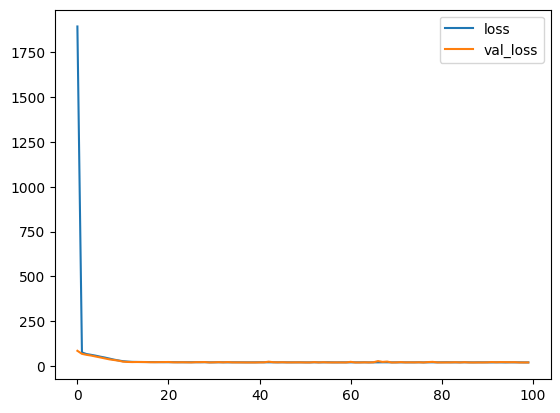

In [10]:
#Show the learning curves
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()

In [8]:
study_hours = 5.0 # > 0
sleep_hours = 7.0 # > 0
stress_level = 3.0 # 0 - 10
attendance_rate = 0.9 # 0.0-1.0
caffeine_intake = 2.0 # 0 - 6?

X_new = np.array([[study_hours, sleep_hours, stress_level, attendance_rate, caffeine_intake]])

# Predykcja
predicted_performance = model.predict(X_new)

print("Przewidywany performance_index:", predicted_performance[0][0])

1/1 [==============================] - 0s 60ms/step
Przewidywany performance_index: 100.13955


In [9]:
model.save("base_model.h5")

c:\Users\HANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
